# Tutorial 4: Integration of spatial transcriptome-proteome with histology image human tonsil dataset.

This notebook provides a step-by-step guide on how to obtain joint embeddings on the human tonsil dataset.

In [16]:
# Import required libraries and dependencies
import json
import torch
import warnings
import scanpy as sc
import matplotlib.pyplot as plt

from PIL import Image
from maple.model import *
from maple.utils import *
from maple.hipt_4k import *
from maple.preprocess import *
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Initialize global settings
seed = 114512
fix_seed(seed)
Image.MAX_IMAGE_PIXELS = None
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore", category=UserWarning)

Global random seed set to: 114512.


In [17]:
# Obtain morphological embeddings using pre-trained HIPT
img = Image.open('../data/human_tonsil/he_raw.tif')

with open('../data/human_tonsil/scalefactors_json.json', 'r') as f:
    scales = json.load(f)
pixel_size_raw = 65 / scales['spot_diameter_fullres']
pixel_size = 0.5
rad = 55 / (2 * pixel_size_raw)
locs = pd.read_csv('../data/human_tonsil/tissue_positions_list.csv', index_col=0)
locs.columns = [str(i) for i in range(1, 6)]

img_emb = get_hipt_features(img, locs, rad, pixel_size_raw, pixel_size, pretrained=True, device=device)

Scaling image
Preprocessing image
Adjusting margins


Extracting image features: 4/4: 100%|██████████| 4/4 [00:39<00:00,  9.85s/it]


Smoothing embeddings


In [18]:
# Load the molecular data of the human tonsil dataset and transcriptome-proteome mapping table
adata_rna = sc.read_h5ad('../data/human_tonsil/adata_rna.h5ad')
adata_pro = sc.read_h5ad('../data/human_tonsil/adata_pro.h5ad')
mapping_df = pd.read_csv('../data/feature_prior/pro2gene.csv')

# Retrieve genes corresponding to proteins for feature alignment
custom_mapping = {}
for _, row in mapping_df.iterrows():
    pro_name = str(row['protein name']).strip()
    rna_names = str(row['gene name']).replace('/', ',').split(',') 
    custom_mapping[pro_name] = [g.strip() for g in rna_names if g.strip() and g.strip() != 'nan']
    
target_rna = []
all_pro_symbols = adata_pro.var['gene_symbol'].astype(str).tolist()
for pro_name in all_pro_symbols:
    target_genes = custom_mapping.get(pro_name, [pro_name])
    target_rna.extend(target_genes)
target_rna = list(set(target_rna))

# Preprocess the RNA data, retain genes corresponding to proteins for feature alignment
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.highly_variable_genes(adata_rna, flavor='seurat_v3', n_top_genes=3000)
valid_to_protect = [g for g in target_rna if g in adata_rna.var_names]
adata_rna.var.loc[valid_to_protect, 'highly_variable'] = True
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna)
adata_rna.obsm['X_feat'] = compute_pca(adata_rna[:, adata_rna.var['highly_variable']].X, 40)

# Preprocess the protein data
adata_pro.layers['counts'] = adata_pro.X.copy()
clr_normalize_each_cell(adata_pro)
sc.pp.scale(adata_pro)
adata_pro.obsm['X_feat'] = compute_pca(adata_pro.X, adata_pro.n_vars-1)

# Inspect the processed molecular data
adata_rna, adata_pro

(AnnData object with n_obs × n_vars = 4194 × 18085
     obs: 'annotation'
     var: 'gene_ids', 'feature_types', 'genome', 'gene_symbol', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
     uns: 'hvg', 'log1p'
     obsm: 'spatial', 'X_feat'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 4194 × 35
     obs: 'annotation'
     var: 'gene_ids', 'feature_types', 'gene_symbol', 'mean', 'std'
     obsm: 'spatial', 'X_feat'
     layers: 'counts')

In [19]:
# Create a MAPLE model and initialize it
maple = MAPLE(
        adata_rna=adata_rna,
        adata_pro=adata_pro,
        img_emb=img_emb,
        device=device
    )

# Train the MAPLE model
maple.train_modal()

The spatial, feature, and joint graphs have been successfully generated.
Loaded pre-computed real gene ontology graph from '../data/feature_prior/go_graphs/go_graph_20260522_185557.npz'.
The spatial, feature, and joint graphs have been successfully generated.
The real cross-modal translational graph has been successfully generated.


Training:  25%|██▍       | 491/2000 [00:05<00:15, 94.51it/s, recon_loss_rna=0.672531, recon_loss_pro=0.132122, trans_loss=0.186914, total_loss=0.823345]

Early stopping triggered at epoch 492.
Total training time: 5.20 seconds.
Peak GPU memory usage: 387.84 MB.


In [20]:
# Prepare a new AnnData for unified qualitative and quantitative analysis
adata = adata_rna.copy()

# Extract the joint embeddings
with torch.no_grad():
    maple.eval()
    results = maple.forward()
    adata.obsm['maple_emb'] = results['joint_emb'].cpu().numpy()

# Perform Leiden clustering on the joint embeddings
optimize_leiden(adata=adata, n_clusters=10, used_obsm='maple_emb',
                add_obs='maple_leiden', res_min=0.1, res_max=1.0)

# Identify GCs using clustering results
idenfity_germinal_centers(adata=adata, cluster_key='maple_leiden', threshold=0.3)

Current resolution is 0.5500, found 9 clusters.
Current resolution is 0.7750, found 12 clusters.
Current resolution is 0.6625, found 10 clusters.
Success: Leiden found 10 clusters at resolution 0.6625 (Attempt 3).


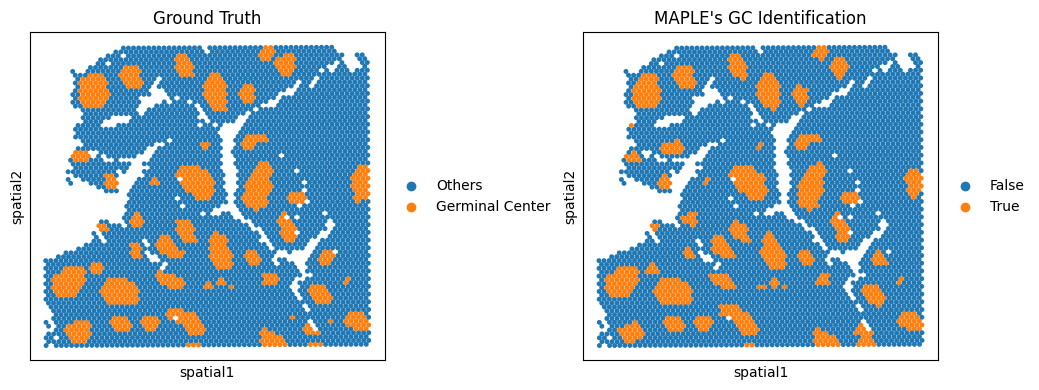

In [21]:
# Visualize spatial GC distribution and MAPLE's GC identification
fig, ax_list = plt.subplots(1, 2, figsize=(10.5, 4))

sc.pl.embedding(adata, basis='spatial', title='Ground Truth', color='annotation', ax=ax_list[0], s=50, show=False)
sc.pl.embedding(adata, basis='spatial', title='MAPLE\'s GC Identification', color='maple_is_GC', ax=ax_list[1], s=50, show=False)
ax_list[0].invert_yaxis()
ax_list[1].invert_yaxis()

plt.tight_layout(w_pad=0.5)
plt.show()

In [22]:
# Calculate supervised metrics for GC identification
true_GC = (adata.obs['annotation'] == 'Germinal Center').tolist()
pred_GC = adata.obs['maple_is_GC']

Acc = accuracy_score(true_GC, pred_GC)
Pre = precision_score(true_GC, pred_GC)
Rec = recall_score(true_GC, pred_GC)
F1 = f1_score(true_GC, pred_GC)
FPR, TPR, _ = roc_curve(true_GC, pred_GC)
AUC = auc(FPR, TPR)

print(f'Acc: {Acc:.4f}, Pre: {Pre:.4f}, Rec: {Rec:.4f}, F1: {F1:.4f}, AUC: {AUC:.4f}.')

Acc: 0.9754, Pre: 0.9495, Rec: 0.9133, F1: 0.9310, AUC: 0.9512.
